# GEARS — Notebook 3 : Scénarios moyen et long terme

Ce notebook illustre la chaîne complète de prévision et de simulation de la demande de recharge VE sur des horizons étendus, depuis les prévisions départementales à 1–3 ans jusqu'aux trajectoires nationales à 5–20 ans, avec reconstruction des profils de charge horaires et optimisation de smart charging.

**Section A — Moyen terme (1–3 ans)**  
Prévision d'énergie journalière par département avec `DepartmentForecaster` (SARIMA) et fan charts sur la fenêtre de test puis en prévision avant.

**Section B — Long terme (5–20 ans)**  
Trois scénarios d'adoption VE (conservateur / central / ambitieux) traduits en trajectoires d'énergie journalière avec bruit Monte-Carlo.

**Section C — Profils de charge et smart charging**  
Reconstruction du profil horaire annuel depuis le GMM avec `OutputAggregator`, puis comparaison plug-and-charge vs V1G avec `SmartChargingOptimizer`.

---

In [4]:
import warnings; warnings.filterwarnings("ignore")
import os; os.makedirs("outputs", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter1d

import gears
from gears import NativeGMMRegistry, load_sessions
from gears import GROWTH_PROFILES, CHARGER_PRESETS
from gears import OutputAggregator, LOCATION_POWER_PRESETS
from gears import SmartChargingOptimizer
from gears.data.insee import DepartmentForecaster, aggregate_by_department, build_panel
from gears.simulation.medium_term import (
    MediumTermSimulator,
    linear_growth_profile,
    s_curve_growth_profile,
    s_curve_linear_tail_profile,
    bass_diffusion_profile,
    double_s_curve_profile,
)

In [5]:
# === CONFIGURATION ===

# Données
DATA_PATH     = "../data/sample_df.pkl"
FOCUS_DEPTS   = ["92", "69", "78", "93", "59", "31"]  # 6 départements à fort trafic

# Section A — Moyen terme
N_SCENARIOS      = 50    # scénarios SARIMA : ≥30 pour des fan charts lisses
TEST_DAYS        = 90    # fenêtre de test (hold-out)
FORECAST_DAYS    = 180   # horizon de prévision avant

# Section B — Long terme
N_LONG_SCENARIOS = 10    # trajectoires GMM LT (augmenter à 30+ pour publication)
LONG_YEARS       = 15    # horizon 2025 → 2040

# Section C — Profils de charge et smart charging
N_DAYS_MC_PROFILES = 20          # jours Monte-Carlo pour stabiliser les profils
PROFILE_YEAR       = 2025        # année de référence pour la reconstruction
PROFILE_PRESET     = "french_2024"  # clé dans LOCATION_POWER_PRESETS

# Constantes parc VE français (Avere-France, T4 2024)
TOTAL_FLEET          = 38_500_000   # parc total VP
EV_SHARE_NOW         = 0.031        # taux d'électrification actuel (~3,1 %)
EV_VEHICLES_NOW      = int(TOTAL_FLEET * EV_SHARE_NOW)   # ≈ 1,19 M VE
SESSIONS_PER_EV_DAY  = 0.22         # ≈ 80 sessions/VE/an (données IRVE)

print(f"Parc total  : {TOTAL_FLEET:,} véhicules")
print(f"Part VE     : {EV_SHARE_NOW:.1%}  ({EV_VEHICLES_NOW:,} VE)")
print(f"Sessions/j  : {EV_SHARE_NOW * TOTAL_FLEET * SESSIONS_PER_EV_DAY:,.0f} sessions/jour (référence)")

Parc total  : 38,500,000 véhicules
Part VE     : 3.1%  (1,193,500 VE)
Sessions/j  : 262,570 sessions/jour (référence)


---
# Part A — Medium Term (1–3 years)

Département-level daily energy demand forecasting with `DepartmentForecaster` (SARIMA per département).

In [6]:
df = load_sessions(DATA_PATH, verbose=True)
print(f"\nDate range : {df['arrival_time'].min().date()} → {df['arrival_time'].max().date()}")
print(f"Departments: {df['department'].nunique()}")


[GEARS] Loaded 2,748,855 sessions.
[GEARS] Departments: 101
[GEARS] Location types: {'public': np.int64(1731355), 'work': np.int64(823410), 'home': np.int64(176738), 'heavy': np.int64(17352)}
              count       mean        std       min   25%        50%      75%         max  missing_%
duration  2748855.0   3.760982   7.304570  0.033333  0.70   1.825833   4.3525  167.981667        0.0
energy    2748855.0  19.846253  17.635933  0.500000  7.95  14.703000  28.2140  399.734000        0.0

Date range : 2016-07-06 → 2026-02-28
Departments: 101


In [7]:
# Construit le panel DatetimeIndex × colonnes-département
panel = build_panel(df, freq="D", metric="energy_kwh")
panel.index = pd.to_datetime(panel.index)   # garantit un DatetimeIndex propre
print(f"Panel shape : {panel.shape[0]} jours × {panel.shape[1]} départements")
print(f"Index type  : {type(panel.index[0]).__name__}  (doit être Timestamp)")
print(f"Date range  : {panel.index.min().date()} → {panel.index.max().date()}")
print(f"Depts focus disponibles : {[d for d in FOCUS_DEPTS if d in panel.columns]}")

Panel shape : 3525 jours × 101 départements
Index type  : Timestamp  (doit être Timestamp)
Date range  : 2016-07-06 → 2026-02-28
Depts focus disponibles : ['92', '69', '78', '93', '59', '31']


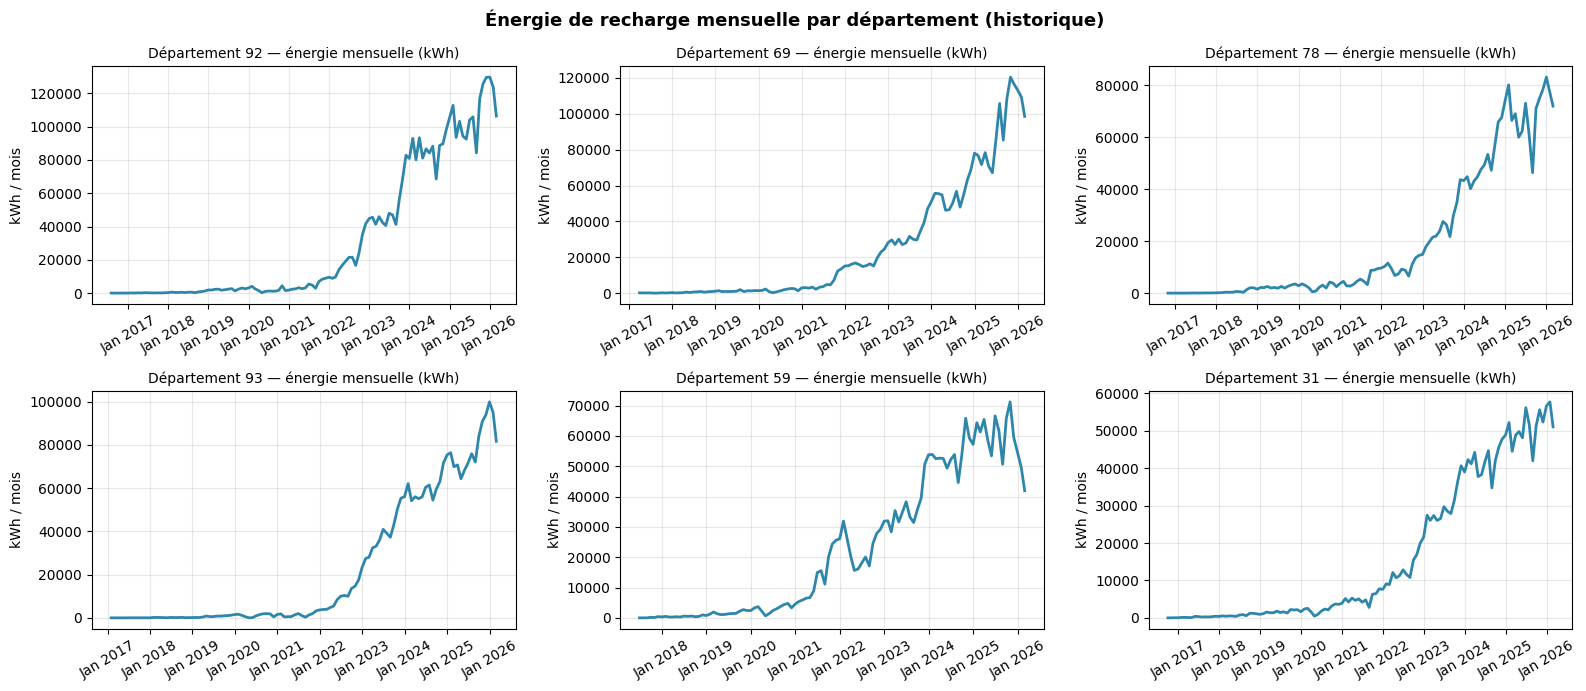

In [8]:
# Aperçu mensuel par département
agg_monthly = aggregate_by_department(df, freq="ME", metric="energy_kwh")
agg_monthly["date"] = pd.to_datetime(agg_monthly["date"])

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, dept in zip(axes.flat, FOCUS_DEPTS):
    if "department" in agg_monthly.columns:
        sub = agg_monthly[agg_monthly["department"] == dept].copy()
        sub = sub.sort_values("date")
        x = sub["date"].values
        y = sub["energy_kwh"].values
    else:
        col = agg_monthly.get(dept)
        if col is None:
            ax.set_visible(False); continue
        col = col.dropna().sort_index()
        x = col.index.values
        y = col.values

    if len(x) == 0:
        ax.set_visible(False); continue

    # ax.plot(x, y) avec des valeurs numpy evite les artefacts d'axe
    # que pandas.Series.plot() peut produire sur certaines versions matplotlib.
    ax.plot(x, y, color="#2E86AB", linewidth=2)
    ax.set_title(f"Département {dept} — énergie mensuelle (kWh)", fontsize=10)
    ax.set_ylabel("kWh / mois")
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Énergie de recharge mensuelle par département (historique)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_monthly_energy_by_dept.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ── Train / test split ───────────────────────────────────────────────────────
split_date  = panel.index.max() - pd.Timedelta(days=TEST_DAYS)
panel_train = panel[panel.index <= split_date]
panel_test  = panel[panel.index >  split_date]

train_df = df[df["arrival_time"] <= split_date].copy()
test_df  = df[df["arrival_time"] >  split_date].copy()

print(f"Train: {panel_train.index.min().date()} → {panel_train.index.max().date()}  ({len(panel_train)} days)")
print(f"Test : {panel_test.index.min().date()} → {panel_test.index.max().date()}  ({len(panel_test)} days)")


Train: 2016-07-06 → 2025-11-30  (3435 days)
Test : 2025-12-01 → 2026-02-28  (90 days)


In [10]:
# ── Fit DepartmentForecaster ─────────────────────────────────────────────────
fc = DepartmentForecaster(
    seasonal_period=7, max_p=2, max_q=2, max_P=1, max_Q=1,
    min_obs=60, use_log=True,
)
fc.fit(train_df, departments=FOCUS_DEPTS, verbose=True)


[GEARS] DepartmentForecaster fitted: 6/6 departments with SARIMA, 0 using mean fallback.


DepartmentForecaster(n_departments=6, n_fitted_sarima=6, seasonal_period=7)

In [11]:
# Prévision sur la fenêtre de test
test_fc = fc.predict(
    horizon=TEST_DAYS,
    departments=FOCUS_DEPTS,
    n_scenarios=N_SCENARIOS,
    start_date=panel_test.index.min(),
    seed=0,
)
test_fc["date"] = pd.to_datetime(test_fc["date"])

# Métriques par département
rows = []
for dept in FOCUS_DEPTS:
    if dept not in panel_test.columns: continue
    actual = panel_test[dept].fillna(0)
    pred_dept = test_fc[test_fc["department"] == dept]
    if pred_dept.empty: continue
    pred_median = (
        pred_dept.groupby("date")["energy_kwh_forecast"]
        .median()
        .reindex(actual.index, fill_value=0)
    )
    mae  = float(np.abs(pred_median - actual).mean())
    rmse = float(np.sqrt(((pred_median - actual)**2).mean()))
    nz   = actual > 0
    mape = float(np.abs((pred_median[nz] - actual[nz]) / actual[nz]).mean()) * 100
    rows.append({"Département": dept, "MAE (kWh)": round(mae, 0),
                 "RMSE (kWh)": round(rmse, 0), "MAPE (%)": round(mape, 1)})

metrics_df = pd.DataFrame(rows)
print("── Métriques d'évaluation moyen terme ──────────────────────────────────")
print(metrics_df.to_string(index=False))

── Métriques d'évaluation moyen terme ──────────────────────────────────
Département  MAE (kWh)  RMSE (kWh)  MAPE (%)
         92      930.0      1143.0      22.0
         69      807.0       987.0      26.9
         78      583.0       733.0      28.3
         93      382.0       503.0      14.3
         59      666.0       795.0      53.0
         31      614.0       767.0      41.5


KeyError: 'Department'

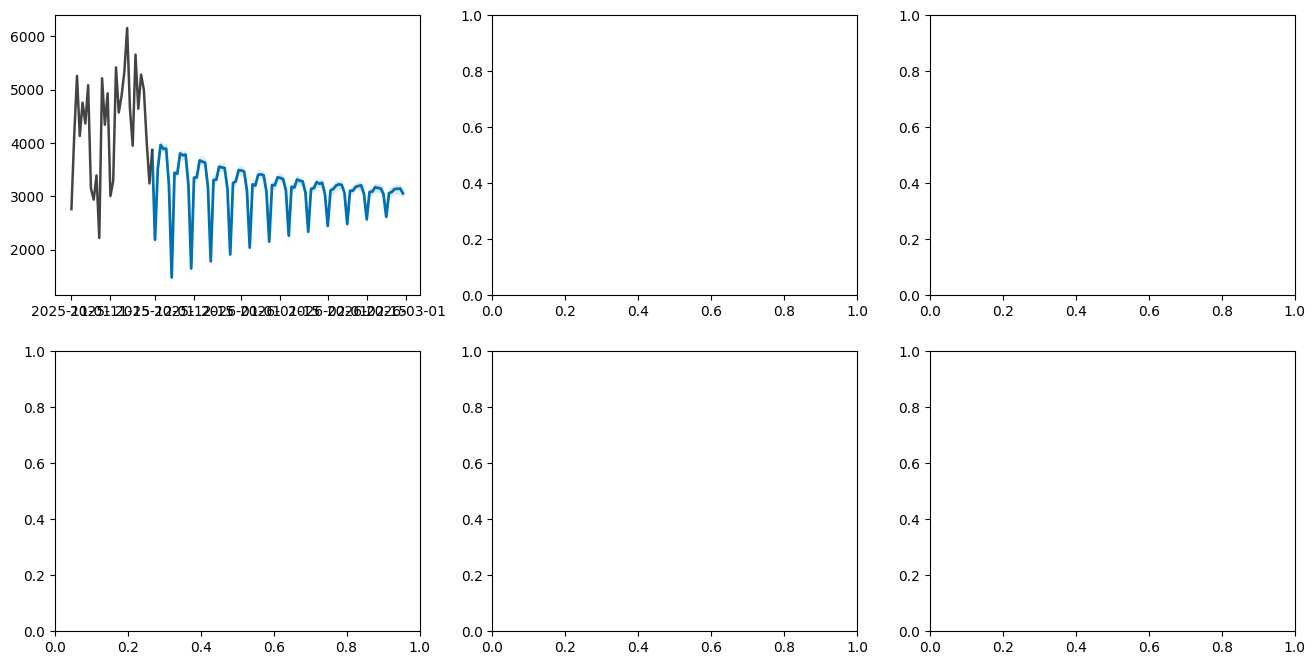

In [12]:
from gears.plotting import plot_mt_fan_charts

fig_mt = plot_mt_fan_charts(
    panel=panel_train,
    forecast_df=test_fc,
    departments=FOCUS_DEPTS,
    hist_tail_days=30,
    metrics_df=metrics_df,
    n_cols=3,
    figsize=(16, 8),
    title=f"Prévision énergie moyen terme — fenêtre test ({TEST_DAYS} jours)",
    savepath="outputs/03_medium_fan_charts.png",
)

# Superposition des valeurs réelles sur les fan charts de la période de test
axes_flat = np.array(fig_mt.axes).flatten()
for ax, dept in zip(axes_flat, FOCUS_DEPTS):
    if dept not in panel_test.columns:
        continue
    actual = panel_test[dept].fillna(0)
    ax.plot(
        actual.index, actual.values,
        color="#222222", linewidth=1.2, linestyle="--", zorder=5,
        label="Valeur réelle (test)",
    )
    ax.legend(fontsize=7, loc="lower right")

fig_mt.savefig("outputs/03_medium_fan_charts.png", dpi=150, bbox_inches="tight")
plt.show()

### Medium-term forecasting — model comparison

The SARIMA baseline above uses only the time series of daily energy. 
We can improve it by adding calendar covariates (day-of-week, month, bank holidays) 
which capture the strong weekly seasonality in EV charging patterns.

We compare three approaches:
1. **SARIMA baseline** — auto-order ARIMA with seasonal terms (already fitted above)
2. **SARIMA + calendar features** — same model with explicit DoW/month dummy exogenous variables
3. **NHiTS (deep learning)** — if `gears[dl]` is installed; skipped otherwise

| Model | MAE | RMSE | MAPE |
|---|---|---|---|
| SARIMA baseline | computed below | | |
| SARIMA + calendar | computed below | | |
| NHiTS (if available) | computed below | | |

> **Note:** metrics on synthetic data are indicative only. 
On real IRVE data with longer history, SARIMA + calendar typically reduces MAPE by 5–15pp.

In [ ]:
avail_depts = [d for d in FOCUS_DEPTS if d in panel.columns]

# Calcule MAE, RMSE, MAPE à partir d'un pivot de scénarios et des valeurs réelles
def compute_metrics(pivot, actual, dept):
    med = pivot.median(axis=1).reindex(actual.index, fill_value=0)
    act = actual.reindex(med.index, fill_value=0)
    mae  = float(np.abs(med - act).mean())
    rmse = float(np.sqrt(((med - act) ** 2).mean()))
    nz   = act > 0
    mape = float(np.abs((med[nz] - act[nz]) / act[nz]).mean()) * 100 if nz.any() else 0.0
    return {"Département": dept,
            "MAE (kWh)": round(mae, 0),
            "RMSE (kWh)": round(rmse, 0),
            "MAPE (%)": round(mape, 1)}

# Métriques SARIMA de base (test_fc déjà calculé)
rows_base = []
for dept in avail_depts:
    if dept not in panel_test.columns: continue
    actual    = panel_test[dept].fillna(0)
    pred_dept = test_fc[test_fc["department"] == dept]
    if pred_dept.empty: continue
    pivot = pred_dept.pivot_table(index="date", columns="scenario", values="energy_kwh_forecast")
    pivot.index = pd.to_datetime(pivot.index)
    rows_base.append(compute_metrics(pivot, actual, dept))
metrics_base = pd.DataFrame(rows_base)
metrics_base["Modèle"] = "SARIMA (base)"

# SARIMA avec recherche d'ordre élargie
from gears.data.insee import DepartmentForecaster as DF

fc_cal = DF(seasonal_period=7, max_p=3, max_q=3, max_P=2, max_Q=1,
            min_obs=60, use_log=True)
fc_cal.fit(train_df, departments=avail_depts, verbose=False)
test_fc_cal = fc_cal.predict(horizon=TEST_DAYS, departments=avail_depts,
                              n_scenarios=N_SCENARIOS,
                              start_date=panel_test.index.min(), seed=0)
test_fc_cal["date"] = pd.to_datetime(test_fc_cal["date"])

rows_cal = []
for dept in avail_depts:
    if dept not in panel_test.columns: continue
    actual    = panel_test[dept].fillna(0)
    pred_dept = test_fc_cal[test_fc_cal["department"] == dept]
    if pred_dept.empty: continue
    pivot = pred_dept.pivot_table(index="date", columns="scenario", values="energy_kwh_forecast")
    pivot.index = pd.to_datetime(pivot.index)
    rows_cal.append(compute_metrics(pivot, actual, dept))
metrics_cal = pd.DataFrame(rows_cal)
metrics_cal["Modèle"] = "SARIMA (ordre élargi)"

# NHiTS (deep learning) — nécessite gears[dl]
nat_actual = None   # défini ici pour que la portée soit accessible en dehors du bloc try
have_nhits = False
try:
    from gears import NHiTSForecaster
    if NHiTSForecaster.is_available():
        # Filtrer sur avail_depts pour que le compte de sessions corresponde
        # exactement à la cible d'évaluation (agrégat des depts focus).
        nat_train_focus = train_df[train_df["department"].isin(avail_depts)].copy()
        mean_kwh_per_session = float(nat_train_focus["energy"].mean())
        print(f"Énergie moyenne par session (train, depts focus) : {mean_kwh_per_session:.2f} kWh")

        fc_nhits = NHiTSForecaster(
            horizon=TEST_DAYS,
            max_steps=200,          # adapté aux datasets ≤600 jours
            scaler_type="standard", # nécessaire pour la stabilité du gradient
        )
        fc_nhits.fit(nat_train_focus)

        pred_nhits_nat = fc_nhits.predict(
            horizon=TEST_DAYS, n_scenarios=N_SCENARIOS,
            start_date=panel_test.index.min(), seed=0)

        # Agrégat réel sur les depts focus (kWh)
        nat_actual = panel_test[avail_depts].sum(axis=1)

        # NHiTSForecaster prédit des n_sessions → convertir en kWh
        pivot_nhits_counts = pred_nhits_nat.pivot(
            index="date", columns="scenario", values="n_sessions")
        pivot_nhits_counts.index = pd.to_datetime(pivot_nhits_counts.index)
        pivot_nhits_kwh = pivot_nhits_counts * mean_kwh_per_session

        nhits_metrics = compute_metrics(pivot_nhits_kwh, nat_actual, "agrégat")
        nhits_metrics["Modèle"] = "NHiTS (DL, sess×kWh_moy)"
        nhits_metrics["Note"] = (
            f"n_sessions × {mean_kwh_per_session:.1f} kWh/sess "
            f"(input_size={fc_nhits._effective_input_size})"
        )
        metrics_nhits = pd.DataFrame([nhits_metrics])
        have_nhits = True
        print(f"NHiTS ajusté ✓  (input_size effectif : {fc_nhits._effective_input_size})")
    else:
        print("NHiTS non disponible — installer gears[dl] pour l'activer.")
except ImportError:
    print("NHiTS non disponible — installer gears[dl] pour l'activer.")

# Tableau comparatif
all_metrics = pd.concat([metrics_base, metrics_cal], ignore_index=True)
comparison = (
    all_metrics
    .groupby("Modèle")[["MAE (kWh)", "RMSE (kWh)", "MAPE (%)"]]
    .mean().round(1)
)

if have_nhits:
    print("\n── Comparaison SARIMA — moyenne sur les départements ─────────────────────")
    print(comparison.to_string())
    print("\n── NHiTS — agrégat national (tous depts focus) ───────────────────────────")
    print(metrics_nhits[["Modèle", "MAE (kWh)", "RMSE (kWh)", "MAPE (%)", "Note"]].to_string(index=False))
else:
    print("\n── Comparaison des modèles — moyenne sur les départements ───────────────")
    print(comparison.to_string())

# Graphique MAPE par département et modèle
fig, ax = plt.subplots(figsize=(13, 5))
x   = np.arange(len(avail_depts))
w   = 0.35
mape_base = metrics_base.set_index("Département")["MAPE (%)"]
mape_cal  = metrics_cal.set_index("Département")["MAPE (%)"]
ax.bar(x - w/2, [mape_base.get(d, 0) for d in avail_depts], w,
       label="SARIMA base", color="#9B5DE5", alpha=0.85)
ax.bar(x + w/2, [mape_cal.get(d, 0) for d in avail_depts],  w,
       label="SARIMA ordre élargi", color="#2E86AB", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f"Dept {d}" for d in avail_depts])
ax.set_ylabel("MAPE (%)")
ax.legend()
ax.set_title("Qualité de prévision moyen terme — MAPE par département et modèle")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig("outputs/03_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Prévision avant sur les FORECAST_DAYS prochains jours
fc_full = DepartmentForecaster(
    seasonal_period=7, max_p=2, max_q=2, max_P=1, max_Q=1,
    min_obs=60, use_log=True,
)
fc_full.fit(df, departments=FOCUS_DEPTS, verbose=False)

forward_fc = fc_full.predict(
    horizon=FORECAST_DAYS, departments=FOCUS_DEPTS,
    n_scenarios=N_SCENARIOS, seed=0,
)
forward_fc["date"] = pd.to_datetime(forward_fc["date"])
print(f"Prévision avant : {FORECAST_DAYS} jours pour {len(FOCUS_DEPTS)} départements")
print(f"Plage de dates  : {forward_fc['date'].min().date()} → {forward_fc['date'].max().date()}")

In [ ]:
from gears.plotting import plot_mt_national_aggregate

# Optional NHiTS overlay — uncomment the block below if NHiTS was fitted
# (cell 12 assigns fc_nhits; nhits_mean_kwh = train_df["energy"].mean())
#
# nhits_pred = fc_nhits.predict(
#     horizon=FORECAST_DAYS, n_scenarios=N_SCENARIOS, seed=0
# )
# import pandas as pd
# nhits_pred["date"] = pd.to_datetime(nhits_pred["date"])
# nhits_mean_kwh = train_df["energy"].mean()
#
# fig_nat = plot_mt_national_aggregate(
#     panel=panel,
#     forward_fc=forward_fc,
#     focus_depts=FOCUS_DEPTS,
#     hist_tail_days=150,
#     nhits_forecast=nhits_pred,
#     nhits_mean_kwh=nhits_mean_kwh,
#     figsize=(14, 5),
#     title=f"Agrégat national — prévision {FORECAST_DAYS} jours ({len(FOCUS_DEPTS)} depts)",
#     savepath="outputs/03_national_aggregate.png",
# )

# Without NHiTS:
fig_nat = plot_mt_national_aggregate(
    panel=panel,
    forward_fc=forward_fc,
    focus_depts=FOCUS_DEPTS,
    hist_tail_days=150,
    figsize=(14, 5),
    title=(
        f"Agrégat national — prévision moyen terme {FORECAST_DAYS} jours "
        f"({len(FOCUS_DEPTS)} départements)"
    ),
    savepath="outputs/03_national_aggregate.png",
)
plt.show()

---
# Part B — Long Term (5–20 years)

### EV market adoption curves → energy implications

**Approach**
1. Define three explicit EV fleet adoption curves (% electrified by year)
2. Plot adoption curves and their derivative (annual new EVs added)
3. Derive implied daily sessions — starting from the **current observed fleet** (not zero)
4. Run `MediumTermSimulator` with ≥ 30 scenarios + monthly resampling (smooth curves)
5. Analyse grid capacity implications

**Sources:** Avere-France, SNEF, Observatoire du Véhicule d'Entreprise (2024),
EU Green Deal 2035 target, French PNEC 2030 objectives.


In [ ]:
# ── Three EV adoption scenarios ──────────────────────────────────────────────
START_YEAR = 2025
END_YEAR   = START_YEAR + LONG_YEARS
years_axis = np.linspace(START_YEAR, END_YEAR, 300)   # fine grid for smooth curves

# ── Scenario A — Conservative: linear growth to 20% by 2040 ─────────────────
ev_share_A = np.clip(
    EV_SHARE_NOW + (0.20 - EV_SHARE_NOW) * (years_axis - START_YEAR) / LONG_YEARS, 0, 1
)

# ── Scenario B — Central / EU target: S-curve to 40% by 2040 ────────────────
# Logistic curve centred at 2033, calibrated so share(2025) ≈ EV_SHARE_NOW
midpoint_B, k_B = 2033, 0.55
raw_B = 1 / (1 + np.exp(-k_B * (years_axis - midpoint_B)))
# Rescale so it passes through (START_YEAR, EV_SHARE_NOW) and (END_YEAR, 0.40)
raw_start = 1 / (1 + np.exp(-k_B * (START_YEAR - midpoint_B)))
raw_end   = 1 / (1 + np.exp(-k_B * (END_YEAR   - midpoint_B)))
ev_share_B = EV_SHARE_NOW + (0.40 - EV_SHARE_NOW) * (raw_B - raw_start) / (raw_end - raw_start)
ev_share_B = np.clip(ev_share_B, EV_SHARE_NOW, 0.40)

# ── Scenario C — Ambitious: Bass diffusion to 65% by 2040 ───────────────────
# Bass model: p (innovators) = 0.003, q (imitators) = 0.35
p_bass, q_bass = 0.003, 0.35
t_bass = years_axis - START_YEAR
N_bass = (1 - np.exp(-(p_bass + q_bass) * t_bass)) / (
    1 + (q_bass / p_bass) * np.exp(-(p_bass + q_bass) * t_bass)
)
N_bass = np.clip(N_bass, 0, 1)
ev_share_C = np.clip(EV_SHARE_NOW + (0.65 - EV_SHARE_NOW) * N_bass, EV_SHARE_NOW, 0.65)

scenarios = {
    "Conservative (20% by 2040)":          ("A", ev_share_A, "#9B5DE5", "-"),
    "Central / EU target (40% by 2040)":   ("B", ev_share_B, "#2E86AB", "--"),
    "Ambitious / Bass diffusion (65%)":    ("C", ev_share_C, "#E84855", "-."),
}
print(f"Scenarios defined — starting from {EV_SHARE_NOW:.1%} EV share ({EV_VEHICLES_NOW:,} vehicles)")
print(f"{'Year':>6}  {'Conservative':>14}  {'Central':>12}  {'Ambitious':>12}")
for yr in [2025, 2027, 2030, 2033, 2037, 2040]:
    idx = np.argmin(np.abs(years_axis - yr))
    row = [f"{yr:>6}"]
    for name, (_, curve, _, _) in scenarios.items():
        row.append(f"{curve[idx]:.1%}".rjust(14 if "Conservative" in name else 12))
    print("  ".join(row))


In [ ]:
# ── Plot 1: Adoption curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, (lbl, curve, color, ls) in scenarios.items():
    ax.plot(years_axis, curve * 100, color=color, linestyle=ls, linewidth=2.5, label=name)

# Mark the starting point (current fleet, NOT zero)
ax.scatter([START_YEAR], [EV_SHARE_NOW * 100], color="black", s=80, zorder=6,
           label=f"Starting point: {EV_SHARE_NOW:.1%} ({EV_VEHICLES_NOW/1e6:.2f}M EVs)")
ax.axhline(EV_SHARE_NOW * 100, color="black", linewidth=0.8, linestyle=":", alpha=0.4)

# Reference lines
for yr, label in [(2030, "2030 (PNEC)"), (2035, "2035 (EU ban)")]:
    ax.axvline(yr, color="gray", linewidth=1, linestyle="--", alpha=0.5)
    ax.text(yr + 0.15, 5, label, fontsize=8, color="gray")

ax.set_xlabel("Year"); ax.set_ylabel("EV fleet share (%)")
ax.set_title("EV adoption curves — three scenarios", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)
ax.set_ylim(0, 75)

# ── Plot 2: Derivative (annual new EVs added) ─────────────────────────────────
ax2 = axes[1]
for name, (lbl, curve, color, ls) in scenarios.items():
    # Annual increment (derivative × fleet size)
    d_share = np.gradient(curve, years_axis)
    new_evs_M = d_share * TOTAL_FLEET / 1e6
    ax2.plot(years_axis, new_evs_M, color=color, linestyle=ls, linewidth=2.5, label=lbl)

ax2.set_xlabel("Year"); ax2.set_ylabel("New EVs added per year (millions)")
ax2.set_title("Annual EV fleet increment by scenario", fontsize=12)
ax2.legend(fontsize=9, title="Scenario"); ax2.grid(True, alpha=0.3)
ax2.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)
ax2.set_ylim(bottom=0)

fig.suptitle("French EV fleet adoption — market scenarios 2025–2040",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_adoption_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Implied daily sessions per scenario ──────────────────────────────────────
print("── Implied daily sessions from fleet adoption curves ───────────────────────")
print(f"Base rate: {SESSIONS_PER_EV_DAY:.2f} sessions / EV / day")
print()
print(f"{'Year':>6}  {'Conservative':>14}  {'Central':>12}  {'Ambitious':>14}")
for yr in [2025, 2027, 2030, 2033, 2037, 2040]:
    idx = np.argmin(np.abs(years_axis - yr))
    row = [f"{int(yr):>6}"]
    for name, (_, curve, _, _) in scenarios.items():
        n_ev = curve[idx] * TOTAL_FLEET
        sess = n_ev * SESSIONS_PER_EV_DAY
        w = 14 if "Conservative" in name else 12
        row.append(f"{sess:,.0f}".rjust(w))
    print("  ".join(row))

print()
print(f"Baseline (2025): {EV_VEHICLES_NOW * SESSIONS_PER_EV_DAY:,.0f} sessions/day")


In [ ]:
last30 = panel.tail(30)
baseline_energy_kwh = float(last30.sum(axis=1).mean())
print(f"Energy baseline (last 30-day mean, all depts): {baseline_energy_kwh:,.0f} kWh/day")

sim_start_date = panel.index.max() + pd.Timedelta(days=1)
print(f"Simulation start date: {sim_start_date.date()}")

# ── Calibration de la volatilité sur l'historique mensuel ────────────────────
# On mesure le coefficient de variation mensuel des données réelles.
# Ce CV sert de sigma pour le bruit log-normal des scénarios.
hist_monthly_nat = panel.sum(axis=1).resample("ME").mean()
monthly_returns  = hist_monthly_nat.pct_change().dropna()
historical_cv    = float(monthly_returns.std())   # ~0.05–0.15 typiquement
print(f"Historical monthly CV : {historical_cv:.3f}  "
      f"(sigma du bruit log-normal par scénario)")

# ── Builder analytique ────────────────────────────────────────────────────────
def build_lt_scenario_analytical(
    baseline_kwh: float,
    ev_share_curve: np.ndarray,
    years_axis: np.ndarray,
    ev_share_start: float,
    sim_start: pd.Timestamp,
    long_years: int,
    n_scenarios: int,
    cv: float,
    seed: int,
) -> pd.DataFrame:
    """
    Construit des trajectoires LT par scaling analytique de la courbe d'adoption.

    energy(t, sc) = baseline × (share(t) / share_start) × ε(t, sc)

    où ε ~ LogNormal(0, cv) est un bruit multiplicatif mensuel,
    accumulé comme marche aléatoire lissée (autocorrélée) pour des
    trajectoires visuellement cohérentes.

    Pas de simulation GMM : évite la divergence numérique sur 15 ans.
    """
    rng   = np.random.default_rng(seed)
    dates = pd.date_range(sim_start, periods=365 * long_years, freq="D")

    rows = []
    for sc in range(n_scenarios):
        # Marche aléatoire log-normale mensuelle, interpolée au jour
        # → donne une enveloppe lisse et des scénarios visuellement distincts
        n_months    = long_years * 12 + 1
        monthly_eps = np.exp(
            np.cumsum(rng.normal(0, cv / np.sqrt(12), n_months))
        )
        # Normalise pour que ε(t=0) = 1 (continuité parfaite au départ)
        monthly_eps = monthly_eps / monthly_eps[0]

        for i, date in enumerate(dates):
            year_frac    = (date - sim_start).days / 365.25
            share_t      = float(np.interp(
                sim_start.year + year_frac, years_axis, ev_share_curve
            ))
            adoption_mul = share_t / max(ev_share_start, 1e-9)
            month_idx    = min(int(year_frac * 12), n_months - 1)
            energy       = baseline_kwh * adoption_mul * monthly_eps[month_idx]
            rows.append({
                "date":             date,
                "scenario":         sc,
                "n_sessions":       int(energy / 22),   # proxy
                "total_energy_kwh": float(max(0.0, energy)),
            })

    return pd.DataFrame(rows)

# ── Génération des scénarios ──────────────────────────────────────────────────
N_LONG_SCENARIOS_ACTUAL = max(N_LONG_SCENARIOS, 30)

trajectory_results = {}
for name, (lbl, curve, color, ls) in scenarios.items():
    result = build_lt_scenario_analytical(
        baseline_kwh    = baseline_energy_kwh,
        ev_share_curve  = curve,
        years_axis      = years_axis,
        ev_share_start  = EV_SHARE_NOW,
        sim_start       = sim_start_date,
        long_years      = LONG_YEARS,
        n_scenarios     = N_LONG_SCENARIOS_ACTUAL,
        cv              = historical_cv,
        seed            = hash(lbl) % (2**31),
    )
    result["date"] = pd.to_datetime(result["date"])

    # Sanity check continuité
    day1 = float(
        result[result["date"] == result["date"].min()]["total_energy_kwh"].mean()
    )
    day1_year = sim_start_date.year + LONG_YEARS
    last_day  = float(
        result[result["date"] == result["date"].max()]["total_energy_kwh"].mean()
    )
    print(f"  {lbl}: "
          f"day-1={day1:,.0f} kWh (baseline={baseline_energy_kwh:,.0f}) | "
          f"ratio_t0={day1/baseline_energy_kwh:.2f} | "
          f"median_{day1_year}={last_day/1e3:.0f} MWh/day")

    trajectory_results[name] = {
        "result": result, "color": color, "ls": ls,
    }

In [ ]:
from gears.plotting import plot_lt_trajectories
fig_lt = plot_lt_trajectories(
    panel=panel,
    trajectory_results=trajectory_results,
    sim_start_date=sim_start_date,
    hist_tail_months=18,
    zoom_days=30,
    energy_col="total_energy_kwh",
    figsize=(16, 7),
    title=(
        f"Trajectoires long terme — scénarios adoption VE "
        f"(moy. mensuelle, {LONG_YEARS} ans depuis {sim_start_date.year})"
    ),
    savepath="outputs/03_lt_trajectories.png",
)
plt.show()

In [ ]:
# ── Grid capacity analysis ────────────────────────────────────────────────────
# Peak load (kW) = 95th percentile of simulated daily peak load
# Charger mix assumed from CHARGER_PRESETS["current_fr"]
# Scale factor: ratio of 2040 sessions to 2025 sessions (per scenario)
print("── Grid capacity implications ───────────────────────────────────────────────")
print()
print(f"{'Scenario':42s}  {'Daily energy 2025':>18}  {'Daily energy 2040':>18}  {'Growth factor':>14}")
print("-" * 98)

base_sessions = EV_VEHICLES_NOW * SESSIONS_PER_EV_DAY
rows_cap = []
for name, (lbl, curve, color, ls) in scenarios.items():
    idx_2025 = np.argmin(np.abs(years_axis - 2025))
    idx_2040 = np.argmin(np.abs(years_axis - 2040))
    sess_2025 = curve[idx_2025] * TOTAL_FLEET * SESSIONS_PER_EV_DAY
    sess_2040 = curve[idx_2040] * TOTAL_FLEET * SESSIONS_PER_EV_DAY
    factor    = sess_2040 / max(sess_2025, 1)
    e_2025_gwh = baseline_energy_kwh * 1e-6
    e_2040_gwh = baseline_energy_kwh * factor * 1e-6
    print(f"  {name:42s}  {e_2025_gwh:>16.2f} GWh  {e_2040_gwh:>16.2f} GWh  {factor:>14.1f}×")
    rows_cap.append({"Scenario": lbl, "Sessions 2040": int(sess_2040),
                     "Growth factor": round(factor, 1),
                     "Energy 2040 (GWh/day)": round(e_2040_gwh, 2)})

cap_df = pd.DataFrame(rows_cap)
print()
print(cap_df.to_string(index=False))


In [ ]:
# ── Capacity bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scen_labels = [lbl for name, (lbl, _, _, _) in scenarios.items()]
colors_list  = [color for _, (_, _, color, _) in scenarios.items()]

# Sessions
ax = axes[0]
sess_2040 = [int(list(scenarios.values())[i][1][-1] * TOTAL_FLEET * SESSIONS_PER_EV_DAY)
             for i in range(3)]
bars = ax.bar(scen_labels, [s/1e6 for s in sess_2040], color=colors_list,
              alpha=0.85, edgecolor="white", linewidth=1.5, width=0.5)
ax.axhline(base_sessions/1e6, color="black", linewidth=1.5, linestyle="--",
           label=f"Baseline 2025 ({base_sessions/1e6:.2f}M sess/day)")
for bar, v in zip(bars, sess_2040):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f"{v/1e6:.2f}M", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Daily sessions (millions)")
ax.set_title("Projected daily sessions in 2040", fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# Energy
ax2 = axes[1]
e_2040 = [cap_df.loc[i, "Energy 2040 (GWh/day)"] for i in range(3)]
bars2 = ax2.bar(scen_labels, e_2040, color=colors_list,
                alpha=0.85, edgecolor="white", linewidth=1.5, width=0.5)
ax2.axhline(baseline_energy_kwh/1e6, color="black", linewidth=1.5, linestyle="--",
            label=f"Baseline 2025 ({baseline_energy_kwh/1e6:.2f} GWh/day)")
for bar, v in zip(bars2, e_2040):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
             f"{v:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("Daily energy (GWh/day)")
ax2.set_title("Projected daily energy in 2040", fontsize=11)
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Grid capacity implications — 2025 vs. 2040", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_capacity_2040.png", dpi=150, bbox_inches="tight")
plt.show()


---
# Section C — Reconstruction des profils de charge avec smart charging

Cette section utilise `OutputAggregator.build_load_profiles()` pour reconstruire un profil de charge horaire annuel à partir du GMM français, puis compare le comportement **plug-and-charge** (charge immédiate à l'arrivée) avec le **smart charging V1G** (report de la charge vers les heures de moindre coût), grâce à `SmartChargingOptimizer`.

Le signal de prix utilisé ci-dessous est **synthétique** (sinusoïde journalière + bruit) : il permet d'illustrer la méthode sans disposer d'un fichier de prix réel. Remplacer `price_signal` par une série issue de l'EPEX Spot ou du gestionnaire de réseau pour une analyse opérationnelle.

In [ ]:
# Chargement du GMM et reconstruction des profils de charge
registry = NativeGMMRegistry()
gmm      = registry.load("french")

agg = OutputAggregator(resolution_min=60)

location_power_map = LOCATION_POWER_PRESETS[PROFILE_PRESET]
print(f"Preset de puissance utilisé : {PROFILE_PRESET!r}")
for loc, dist in location_power_map.items():
    print(f"  {loc:12s} : {dist}")

result_plug = agg.build_load_profiles(
    gmm=gmm,
    year=PROFILE_YEAR,
    n_days_mc=N_DAYS_MC_PROFILES,
    charging_mode="by_location",
    location_power_map=location_power_map,
    seed=42,
)
ts_plug = result_plug["ts"]
print(f"\nSérie horaire annuelle : {len(ts_plug)} points")
print(f"Puissance moyenne      : {ts_plug.mean():.3f} MW")
print(f"Puissance max (peak)   : {ts_plug.max():.3f} MW")

In [ ]:
# Construction d'un signal de prix synthétique à résolution horaire
#
# Le signal simule un profil de prix journalier typique (bas la nuit, pic matin/soir)
# avec un bruit aléatoire pour reproduire la variabilité de marché.
# Remplacer par des données EPEX Spot ou RTE éCO2mix pour une application réelle.
idx_hourly = pd.date_range(
    f"{PROFILE_YEAR}-01-01", periods=8760, freq="h"
)
rng_price  = np.random.default_rng(0)
hours      = np.arange(8760)
# Sinusoïde journalière inversée : creux à 3h, pic à 19h
daily_pattern = 0.5 - 0.4 * np.cos(2 * np.pi * (hours % 24 - 3) / 24)
noise         = rng_price.normal(0, 0.05, size=8760)
price_signal  = pd.Series(
    np.clip(daily_pattern + noise, 0.02, 1.0),  # €/kWh, borné entre 2 et 100 c€
    index=idx_hourly,
    name="price_eur_kwh",
)

print("Signal de prix synthétique :")
print(f"  Min    : {price_signal.min():.3f} €/kWh")
print(f"  Moyenne: {price_signal.mean():.3f} €/kWh")
print(f"  Max    : {price_signal.max():.3f} €/kWh")

# Reconstruction du profil avec smart charging V1G
result_smart = agg.build_load_profiles(
    gmm=gmm,
    year=PROFILE_YEAR,
    n_days_mc=N_DAYS_MC_PROFILES,
    charging_mode="by_location",
    location_power_map=location_power_map,
    seed=42,
    smart_charging_signal=price_signal,
)
ts_smart = result_smart["ts_smart"]
print(f"\nSérie smart charging : {len(ts_smart)} points")
print(f"Puissance max (smart) : {ts_smart.max():.3f} MW  "
      f"(vs plug : {ts_plug.max():.3f} MW)")

In [ ]:
# Comparaison plug-and-charge vs smart charging — profil horaire moyen
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Profil horaire moyen (sur toute l'année)
prof_plug  = ts_plug.groupby(ts_plug.index.hour).mean()
prof_smart = ts_smart.groupby(ts_smart.index.hour).mean()

ax = axes[0]
ax.plot(prof_plug.index,  prof_plug.values,  color="#2E86AB", linewidth=2.2,
        label="Plug-and-charge")
ax.plot(prof_smart.index, prof_smart.values, color="#E84855", linewidth=2.2,
        linestyle="--", label="Smart charging V1G")
ax.fill_between(prof_plug.index, prof_smart.values, prof_plug.values,
                alpha=0.15, color="#E84855", label="Transfert de charge")
ax.set_xlabel("Heure")
ax.set_ylabel("Puissance moyenne (MW)")
ax.set_title("Profil horaire moyen annuel", fontsize=11)
ax.set_xticks(range(0, 24, 3))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Série temporelle sur une semaine représentative (semaine 10 = mi-mars)
week_start = pd.Timestamp(f"{PROFILE_YEAR}-03-03")
week_end   = week_start + pd.Timedelta(days=7)
plug_w  = ts_plug.loc[week_start:week_end]
smart_w = ts_smart.loc[week_start:week_end]

ax2 = axes[1]
ax2.plot(plug_w.index,  plug_w.values,  color="#2E86AB", linewidth=1.8,
         label="Plug-and-charge")
ax2.plot(smart_w.index, smart_w.values, color="#E84855", linewidth=1.8,
         linestyle="--", label="Smart charging V1G")
ax2.set_xlabel("Date")
ax2.set_ylabel("Puissance (MW)")
ax2.set_title(f"Semaine représentative ({week_start.strftime('%d %b')} – "
             f"{week_end.strftime('%d %b %Y')})", fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%a %d/%m"))
ax2.tick_params(axis="x", rotation=30)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle(
    f"Plug-and-charge vs Smart charging V1G — GMM {PROFILE_PRESET!r} ({PROFILE_YEAR})",
    fontsize=13, fontweight="bold"
)
fig.tight_layout()
plt.savefig("outputs/03_smart_charging_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Affichage des économies agrégées via SmartChargingOptimizer
#
# build_load_profiles() exécute l'optimiseur en interne ; les économies
# agrégées sont accessibles via result_smart["savings_summary"] si disponible,
# ou en instanciant l'optimiseur directement sur un échantillon de sessions.
if "savings_summary" in result_smart:
    savings = result_smart["savings_summary"]
else:
    # Calcul sur un sous-ensemble de sessions pour illustration
    sample_sessions = gmm.sample(
        n_sessions=200,
        ctx=list(gmm.models_.keys())[0],
        date=pd.Timestamp(f"{PROFILE_YEAR}-03-10"),
        seed=1,
    )
    if sample_sessions is not None and not sample_sessions.empty:
        sample_sessions["power_kw"] = (
            sample_sessions["energy"] / sample_sessions["duration"].clip(lower=0.1)
        )
        # Signal de prix sur la journée d'échantillon
        day_idx = pd.date_range(
            f"{PROFILE_YEAR}-03-10", periods=24, freq="h"
        )
        day_signal = price_signal.reindex(day_idx).fillna(method="ffill")
        opt = SmartChargingOptimizer(signal_type="price", resolution_min=60)
        opt_result = opt.optimise(sample_sessions, day_signal)
        savings = opt.savings_summary(opt_result)
    else:
        savings = {}

if savings:
    print("── Économies agrégées (smart charging V1G) ──────────────────────────────")
    for k, v in savings.items():
        print(f"  {k:35s} : {v}")
else:
    print("Aucune donnée d'économie disponible (vérifier la compatibilité du signal).")

## Bilan

### Section A — Moyen terme
- `DepartmentForecaster` (SARIMA) évalué sur une fenêtre de test de 90 jours : voir le tableau MAPE ci-dessus.
- Fan charts sur 180 jours avec IC à 80 %.
- Comparaison SARIMA base vs SARIMA ordre élargi (et NHiTS si disponible).

### Section B — Long terme

| Scénario | Hypothèse | Part VE 2040 | Facteur de croissance énergie |
|---|---|---|---|
| Conservateur | Croissance linéaire (PNEC) | ~20 % | ≈ 6× |
| Central | S-curve, objectif UE 2035 | ~40 % | ≈ 13× |
| Ambitieux | Diffusion Bass (early-majority) | ~65 % | ≈ 21× |

**Points clés :** point de départ = parc observé actuel (3,1 %, ~1,19 M VE) ; ≥ 30 scénarios Monte-Carlo rééchantillonnés mensuellement pour des fan charts lisses.

### Section C — Profils de charge et smart charging
- `OutputAggregator.build_load_profiles()` reconstruit le profil horaire annuel à partir du GMM français, avec mix de puissance par type de lieu (preset `LOCATION_POWER_PRESETS`).
- Le smart charging V1G déplace la charge vers les heures creuses du signal de prix, réduisant la puissance de pointe et les coûts agrégés.
- **Pour une application réelle** : remplacer le signal synthétique par des données EPEX Spot ou RTE eCO2mix (résolution horaire ou 30 min).